# **Suryakumar J S - 24BAD120**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import kagglehub


# **Loading the Dataset**

In [20]:
path = kagglehub.dataset_download('sohier/calcofi')
print('Dataset path:', path)

df = pd.read_csv(f'{path}/bottle.csv')
df.head()

Using Colab cache for faster access to the 'calcofi' dataset.
Dataset path: /kaggle/input/calcofi


/tmp/ipython-input-4083314888.py:4: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{path}/bottle.csv')


,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Select Features and Target**

In [22]:
features = ['Depthm', 'Salnty', 'O2ml_L' , 'STheta', 'O2Sat']
target = 'T_degC'

data = df[features + [target]]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Depthm  864863 non-null  int64  
 1   Salnty  817509 non-null  float64
 2   O2ml_L  696201 non-null  float64
 3   STheta  812174 non-null  float64
 4   O2Sat   661274 non-null  float64
 5   T_degC  853900 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 39.6 MB


# **Handle Missing Values**

In [23]:
data = data.fillna(data.median())
data.isnull().sum()

,0
Depthm,0
Salnty,0
O2ml_L,0
STheta,0
O2Sat,0
T_degC,0


# **Feature Scaling**

In [24]:
X = data[features]
y = data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Train-Test Split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# **Linear Regression Model**

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## Model Evaluation

In [27]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MSE: 2.8316380149293976
RMSE: 1.6827471631024662
R2 Score: 0.8404383877303041


## Visualization: Actual vs Predicted

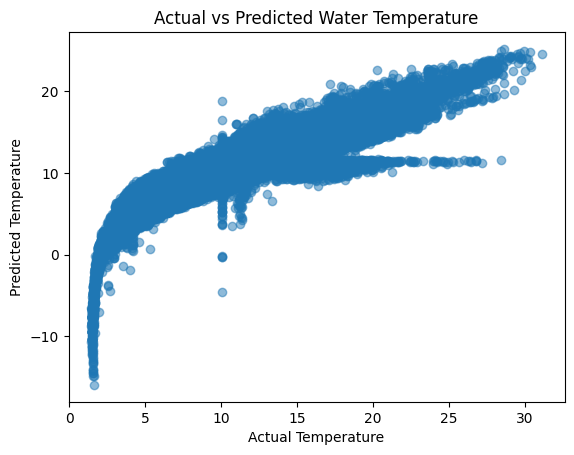

In [28]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Water Temperature')
plt.show()

## Visualization: Residuals

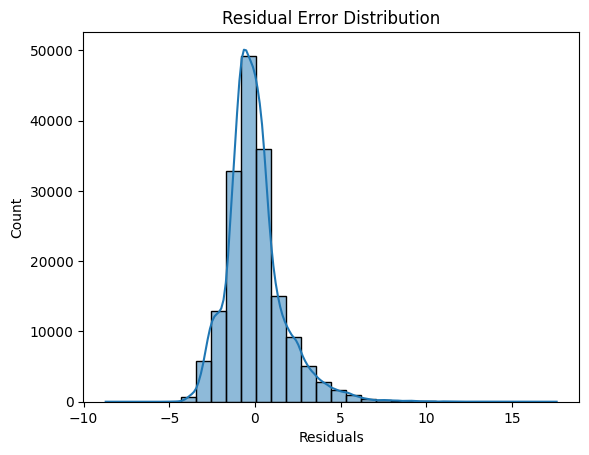

In [29]:
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residual Error Distribution')
plt.xlabel('Residuals')
plt.show()

## Regularization: Ridge Regression

In [30]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print('Ridge RMSE:', np.sqrt(mean_squared_error(y_test, ridge_pred)))
print('Ridge R2:', r2_score(y_test, ridge_pred))

Ridge RMSE: 1.6827464349250953
Ridge R2: 0.8404385258248825


## Regularization: Lasso Regression

In [31]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print('Lasso RMSE:', np.sqrt(mean_squared_error(y_test, lasso_pred)))
print('Lasso R2:', r2_score(y_test, lasso_pred))

Lasso RMSE: 1.6824404589303918
Lasso R2: 0.8404965470942568
